In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

In [29]:
trades = pd.read_csv("/content/ds_ahmed_mushaf/csv_files/historical_data.csv")
sentiment = pd.read_csv("/content/ds_ahmed_mushaf/csv_files/fear_greed_index.csv")

In [30]:
trades.head()
trades.info()
trades.describe()

sentiment.head()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [31]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [38]:
# Trade timestamp is in DD-MM-YYYY format
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True, errors="coerce")

# Sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"], dayfirst=True, errors="coerce")

print("Bad trade timestamps:", trades["Timestamp IST"].isna().sum())
print("Bad sentiment dates:", sentiment["date"].isna().sum())

Bad trade timestamps: 0
Bad sentiment dates: 0


In [39]:
trades = trades.dropna(subset=["Timestamp IST"])
sentiment = sentiment.dropna(subset=["date"])

In [40]:
trades["date"] = trades["Timestamp IST"].dt.date
sentiment["date"] = sentiment["date"].dt.date

In [41]:
df = trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

df.rename(columns={"classification": "sentiment"}, inplace=True)

print(df["sentiment"].value_counts())

sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [42]:
# Drop rows without sentiment
df = df.dropna(subset=["sentiment"])

# Rename columns for easier coding
df = df.rename(columns={
    "Execution Price": "execution_price",
    "Size Tokens": "size_tokens",
    "Size USD": "size_usd",
    "Closed PnL": "closed_pnl",
    "Account": "account"
})

# Ensure numeric
df["execution_price"] = pd.to_numeric(df["execution_price"], errors="coerce")
df["size_tokens"] = pd.to_numeric(df["size_tokens"], errors="coerce")
df["size_usd"] = pd.to_numeric(df["size_usd"], errors="coerce")
df["closed_pnl"] = pd.to_numeric(df["closed_pnl"], errors="coerce")

df = df.dropna(subset=["execution_price", "size_tokens", "size_usd", "closed_pnl"])

In [43]:
# Profit flag
df["is_profit"] = df["closed_pnl"] > 0

# Absolute pnl
df["abs_pnl"] = df["closed_pnl"].abs()

# Risk proxy
df["risk"] = df["size_usd"]

# Trade value
df["trade_value"] = df["size_usd"]


In [45]:
summary = df.groupby("sentiment").agg({
    "closed_pnl": ["mean", "sum"],
    "trade_value": "mean",
    "risk": "mean",
    "is_profit": "mean"
})

summary

closed_pnl                trade_value         risk is_profit
                    mean           sum         mean         mean      mean
sentiment                                                                 
Extreme Fear   34.537862  7.391102e+05  5349.731843  5349.731843  0.370607
Extreme Greed  67.892861  2.715171e+06  3112.251565  3112.251565  0.464943
Fear           54.290400  3.357155e+06  7816.109931  7816.109931  0.420768
Greed          42.743559  2.150129e+06  5736.884375  5736.884375  0.384828
Neutral        34.307718  1.292921e+06  4782.732661  4782.732661  0.396991

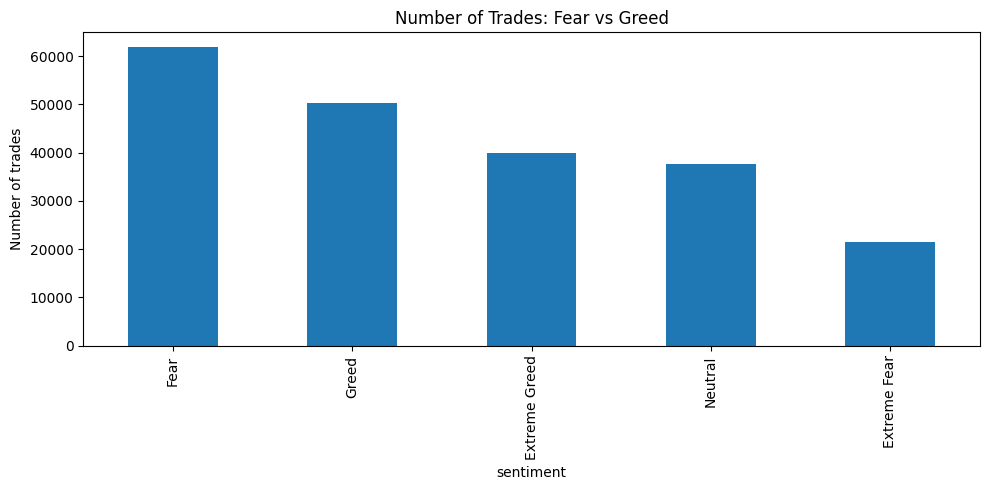

In [47]:
df["sentiment"].value_counts().plot(kind="bar", title="Number of Trades: Fear vs Greed")
plt.ylabel("Number of trades")
plt.tight_layout()
plt.savefig("/content/ds_ahmed_mushaf/outputs/trades_count.png")
plt.show()

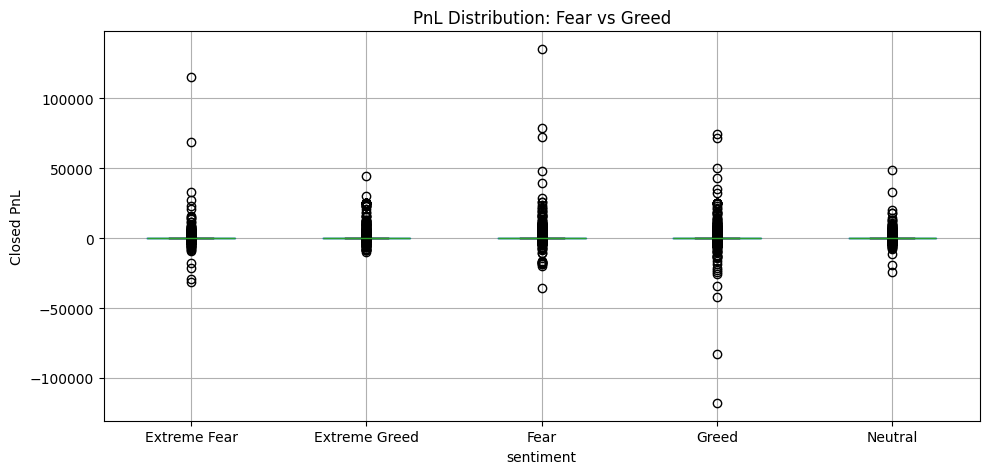

In [48]:
df.boxplot(column="closed_pnl", by="sentiment")
plt.title("PnL Distribution: Fear vs Greed")
plt.suptitle("")
plt.ylabel("Closed PnL")
plt.tight_layout()
plt.savefig("/content/ds_ahmed_mushaf/outputs/pnl_distribution.png")
plt.show()

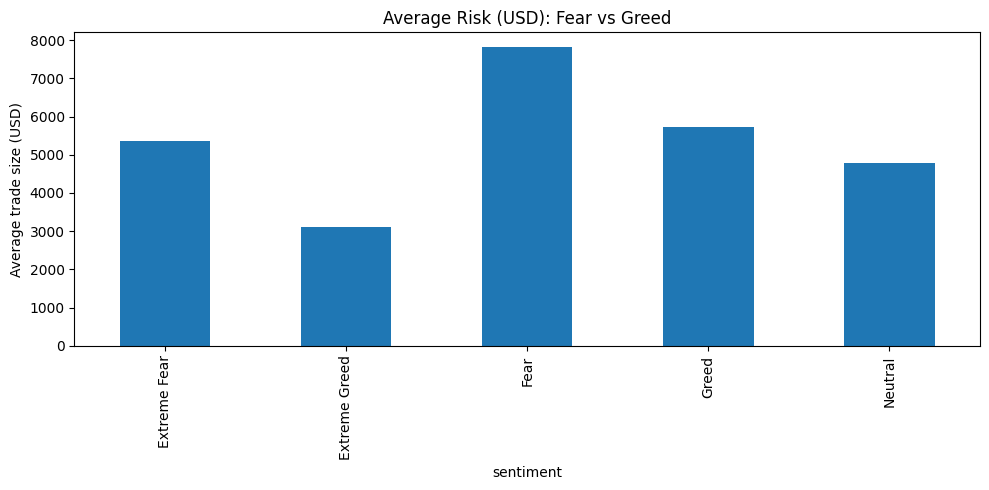

In [49]:
df.groupby("sentiment")["risk"].mean().plot(kind="bar", title="Average Risk (USD): Fear vs Greed")
plt.ylabel("Average trade size (USD)")
plt.tight_layout()
plt.savefig("/content/ds_ahmed_mushaf/outputs/risk_comparison.png")
plt.show()

In [50]:
trader_pnl = df.groupby("account")["closed_pnl"].sum().reset_index()

top_traders = trader_pnl.sort_values("closed_pnl", ascending=False).head(20)["account"]
bottom_traders = trader_pnl.sort_values("closed_pnl").head(20)["account"]

top_df = df[df["account"].isin(top_traders)]
bottom_df = df[df["account"].isin(bottom_traders)]

top_summary = top_df.groupby("sentiment").agg({
    "risk": "mean",
    "is_profit": "mean"
})

bottom_summary = bottom_df.groupby("sentiment").agg({
    "risk": "mean",
    "is_profit": "mean"
})

print("Top traders behavior:")
display(top_summary)

print("Bottom traders behavior:")
display(bottom_summary)

Top traders behavior:


,risk,is_profit
sentiment,,
Extreme Fear,4222.742714,0.388003
Extreme Greed,3393.754177,0.479428
Fear,7894.418569,0.422881
Greed,6778.942172,0.409522
Neutral,4959.548609,0.421774


Bottom traders behavior:


,risk,is_profit
sentiment,,
Extreme Fear,6706.070406,0.321690
Extreme Greed,1215.364370,0.406266
Fear,5697.741135,0.393047
Greed,1927.353843,0.344876
Neutral,2539.993554,0.333987


In [51]:
summary.to_csv("/content/ds_ahmed_mushaf/csv_files/sentiment_summary.csv")